# Gerekli Kütüphaneleri İçe Aktarma

Bu bölümde veri analizi, görselleştirme ve makine öğrenmesi işlemleri için kullanacağımız kütüphaneleri içe aktarıyoruz.

```python
import pandas as pd  # Veri manipülasyonu ve analizi için kullanılır
import numpy as np  # Sayısal işlemler ve veri işlemleri için
import seaborn as sns  # İleri düzey veri görselleştirme için
import matplotlib.pyplot as plt  # Temel grafik çizimleri için
import missingno as msno  # Eksik verilerin görselleştirilmesi için

# Makine öğrenmesi modellerinin doğruluğunu ölçmek için kullanılan metrikler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report 

import warnings  # Uyarıları yönetmek için

# Uyarı mesajlarını bastırma
warnings.filterwarnings('ignore')

# Grafik stili ayarlama
plt.style.use('ggplot')  # ggplot stili, grafiklerde daha estetik bir görünüm sağlar


In [1]:
# Gerekli kütüphaneleri içe aktarma
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import missingno as msno
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import warnings
# Uyarı mesajlarını bastırma
warnings.filterwarnings('ignore')
# Grafik stili ayarlama
plt.style.use('ggplot')

# Veriyi CSV Dosyasından Okuma
Bu bölümde, **pandas** kütüphanesini kullanarak CSV dosyasından veri yüklüyoruz. Veri kümesi, meme kanseri hastalarının özelliklerini içermektedir. Dosya yolunu bilgisayarınızdaki dosya konumuna göre güncellemeyi unutmayın.

In [2]:
# Veriyi CSV dosyasından okuma
df = pd.read_csv('../input/breast-cancer-wisconsin-data/data.csv') #Bilgisayardaki dosya konumuna göre doldurulmalı

# İlk 5 Satırı Gösterme
Bu bölümde, yüklü verinin ilk 5 satırını görüntüleyerek verinin yapısını inceleyeceğiz. Ayrıca, dosyanın düzgün bir şekilde yüklendiğinden emin olmak için hata yönetimi ekledik. 

Eğer dosya bulunamazsa veya dosya boşsa kullanıcıya uygun hata mesajları verilecektir.


In [3]:
# İlk 5 satırı gösterme
try:
    df = pd.read_csv(r'../input/breast-cancer-wisconsin-data/data.csv')#Bilgisayardaki dosya konumuna göre doldurulmalı
    print(df.head())
except FileNotFoundError:
    print("File not found. Please check the path and try again.")
except pd.errors.EmptyDataError:
    print("File is empty. Please check the file.")
except Exception as e:
    print(f"An error occurred: {e}")

         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  texture_worst  perimeter_worst  area_worst  smoothness

# Gereksiz Sütunları Kaldırma
Bu bölümde, veri kümesinde analiz için gereksiz olan sütunları kaldırıyoruz. **id** ve **Unnamed: 32** sütunları, veri analizinde kullanılmadığı için bu sütunları veri çerçevesinden çıkartıyoruz.

In [4]:
# Gereksiz sütunları (id ve 'Unnamed: 32') kaldırma
df.drop(['id', 'Unnamed: 32'], axis = 1, inplace = True) 
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


# 'diagnosis' Sütunundaki Benzersiz Değerleri Görüntüleme
Bu bölümde, veri kümesindeki **diagnosis** sütunundaki benzersiz değerleri görüntüleyerek, meme kanseri teşhisinin nasıl sınıflandırıldığını inceleyeceğiz. Bu sütun, hastaların kanserli veya kanserli olmayan olarak sınıflandırılmasını içermektedir.

In [5]:
# 'diagnosis' sütunundaki benzersiz değerleri görüntüleme
df.diagnosis.unique()

array(['M', 'B'], dtype=object)

# 'diagnosis' Sütununu İkili Hale Getirme
Bu bölümde, **diagnosis** sütunundaki değerleri ikili hale getiriyoruz. Meme kanseri teşhisi için **M** (malign) değerini **1** olarak, **B** (benign) değerini ise **0** olarak atıyoruz. Bu dönüşüm, makine öğrenimi modellemelerinde sınıflandırma işlemi için gereklidir.

In [6]:
# 'diagnosis' sütununu ikili hale getirme (M: 1, B: 0)
df['diagnosis'] = df['diagnosis'].apply(lambda val: 1 if val == 'M' else 0)
df.head()


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


# Verinin Temel İstatistiklerini Gösterme
Bu bölümde, veri çerçevesinin temel istatistiklerini görüntüleyerek, her bir sayısal sütunun ortalama, standart sapma, minimum, maksimum ve yüzdelik değerlerini inceleyeceğiz. Bu istatistikler, verinin dağılımı hakkında bilgi sahibi olmamıza yardımcı olur.

In [7]:
# Verinin temel istatistiklerini gösterme
df.describe()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,0.372583,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,0.483918,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,0.000000,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,0.000000,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,0.000000,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,1.000000,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,1.000000,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


# Verinin Genel Bilgilerini Gösterme
Bu bölümde, veri çerçevesinin genel bilgilerini görüntüleyerek sütun isimleri, veri türleri ve boş değerlerin sayısını inceleyeceğiz. Bu bilgiler, verinin yapısını anlamamıza ve veri ön işleme aşamasında hangi adımları atmamız gerektiğine karar vermemize yardımcı olur.

In [8]:
# Verinin genel bilgilerini gösterme (sütun isimleri, veri türleri, boş değerler)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    int64  
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  area_se                  5

# Her Sütundaki Boş Değer Sayısını Gösterme
Bu bölümde, veri çerçevesindeki her sütunda bulunan boş değerlerin sayısını görüntüleyeceğiz. Bu bilgi, veri temizleme sürecinde hangi sütunların daha fazla dikkat gerektirdiğini belirlememize yardımcı olur.

In [9]:
# Her sütundaki boş değer sayısını gösterme
df.isna().sum()

diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64

# Özelliklerin (Feature) İsimlerini Alma (İlk 10 Sütun)
Bu bölümde, veri çerçevesindeki ilk 10 sütunun isimlerini alıyoruz. Bu özellikler, analiz ve modelleme süreçlerinde kullanılacak verileri temsil etmektedir.

In [10]:
# Özelliklerin (feature) isimlerini alma (ilk 10 sütun)
features_mean = list(df.columns[1:11])

# Malign (M) ve Benign (B) Hastaları Ayırma
Bu bölümde, meme kanseri teşhisi olan hastaları malign (M) ve benign (B) olarak iki gruba ayırıyoruz. Malign hastalar **diagnosis** sütununda **1** (M) olarak, benign hastalar ise **0** (B) olarak temsil edilmektedir. Bu ayrım, veri analizi ve modelleme süreçlerinde kullanılacak.

In [11]:
# Malign (M) ve benign (B) hastaları ayırma
dfM = df[df['diagnosis'] == 1]
dfB = df[df['diagnosis'] == 0]

# Grafik Oluşturma
Bu bölümde, grafiklerin font boyutunu ayarlıyoruz ve 5x2 boyutlarında alt grafikler oluşturuyoruz. Her bir alt grafik, malign (M) ve benign (B) hastalara ait özelliklerin histogramını göstermektedir. Histogramlar, her bir özelliğin dağılımını görsel olarak anlamamıza yardımcı olur.

Histogramlar için bin genişliğini, veri aralığına göre hesaplıyoruz ve her iki grup için normalize edilmiş histogramlar oluşturuyoruz. Alt grafiklerde başlıkları ve legend etiketlerini ayarlayarak daha açıklayıcı bir görsel sunuyoruz.

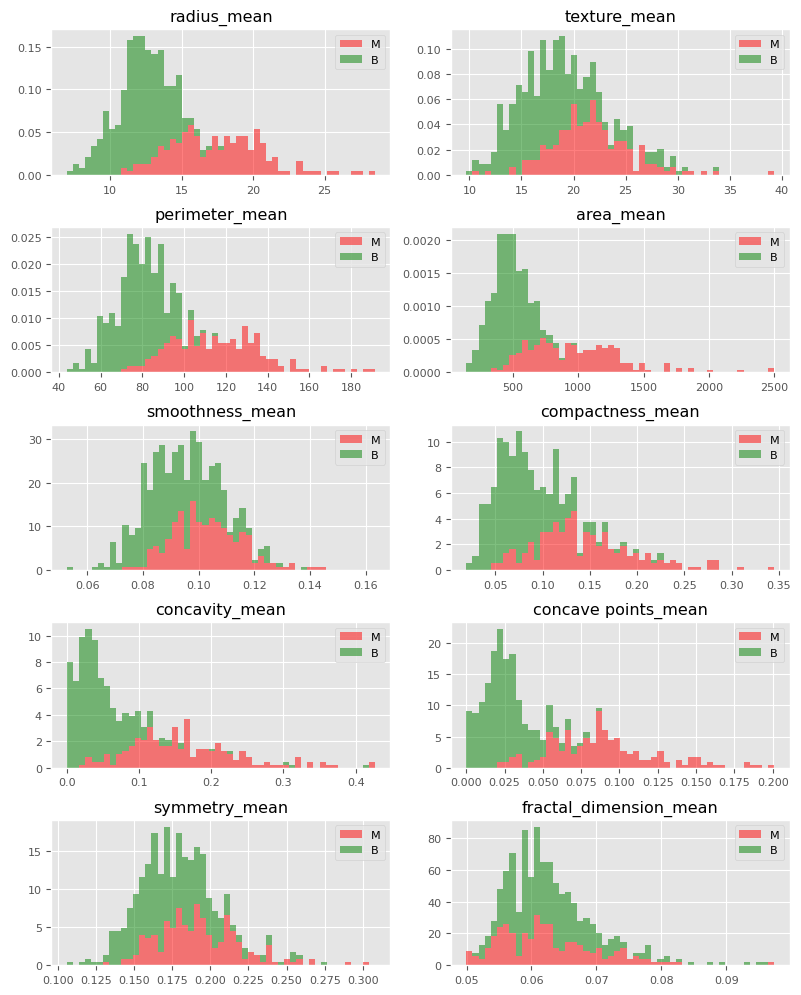

In [12]:
# Grafiklerin font boyutunu ayarlama
plt.rcParams.update({'font.size': 8})

# 5x2 boyutlarında alt grafikler oluşturma
fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(8, 10))
axes = axes.ravel()

for idx, ax in enumerate(axes):
    ax.figure
    binwidth = (max(df[features_mean[idx]]) - min(df[features_mean[idx]])) / 50  # Histogram için bin genişliğini hesaplama
    ax.hist(
        [dfM[features_mean[idx]], dfB[features_mean[idx]]],  # Malign ve benign veriler için histogram çizme
        bins=np.arange(min(df[features_mean[idx]]), max(df[features_mean[idx]]) + binwidth, binwidth),
        alpha=0.5,
        stacked=True,
        density=True,  # Normalize edilmiş histogram
        label=['M', 'B'],  # Legend etiketleri
        color=['r', 'g']  # Renkler
    )
    ax.legend(loc='upper right')  # Legend konumunu ayarlama
    ax.set_title(features_mean[idx])  # Başlık ayarlama
plt.tight_layout()  # Grafiklerin düzenini sıkıştırma
plt.show()  # Grafiği gösterme


Bu grafiklerde, meme kanseri verisinde malignant (M) ve benign (B) tümörlerin bazı özelliklerine göre dağılımları gösteriliyor. Her bir grafik, belirli bir özelliğin tümör tipine göre dağılımını (yeşil: benign, kırmızı: malignant) histogram olarak sunuyor.

Genel yorum:

radius_mean (Yarıçap ortalaması): Malignant tümörler (kırmızı), benign tümörlere (yeşil) göre genellikle daha büyük yarıçapa sahip. Malignant tümörlerin yarıçapları daha yüksek değerlerde yoğunlaşırken, benign tümörler daha düşük yarıçap değerlerinde yoğun.

texture_mean (Doku ortalaması): Malignant ve benign tümörlerin doku ortalamaları arasında belirgin bir ayrım yok gibi, her iki grup da geniş bir aralıkta dağılmış.

perimeter_mean (Çevre ortalaması): Malignant tümörlerin çevre uzunlukları, benign tümörlere göre daha büyük ve yaygın. Bu durum malignant tümörlerin daha geniş çevreye sahip olduğunu gösterir.

area_mean (Alan ortalaması): Malignant tümörlerin alanı genellikle daha büyük. Benign tümörler daha düşük alan değerlerinde toplanırken, malignant tümörler daha geniş bir alana yayılıyor.

smoothness_mean (Pürüzsüzlük ortalaması): Hem malignant hem de benign tümörlerin pürüzsüzlük ortalamaları oldukça benzer görünüyor, ancak malignant tümörler genellikle biraz daha pürüzsüz olabilir.

compactness_mean (Kompaktlık ortalaması): Kompaktlık açısından malignant tümörler, benign tümörlere göre daha yüksek değerler gösteriyor.

concavity_mean (İçbükeylik ortalaması): Malignant tümörler, belirgin şekilde daha yüksek içbükeylik gösteriyor. Benign tümörlerde içbükeylik daha düşük seviyelerde.

concave points_mean (İçbükey noktalar ortalaması): Malignant tümörlerde içbükey noktaların sayısı, benign tümörlere göre daha fazla. Bu, malignant tümörlerin sınırlarının daha düzensiz olduğunu gösterir.

symmetry_mean (Simetri ortalaması): Her iki tümör tipi de simetri açısından çok farklı görünmüyor, ancak malignant tümörler biraz daha yüksek simetriye sahip olabilir.

fractal_dimension_mean (Fraktal boyut ortalaması): Fraktal boyut açısından da çok belirgin bir fark yok gibi, ancak malignant tümörler biraz daha büyük değerlere sahip olabilir.

Bu grafikleri genel olarak yorumlarken, malignant tümörlerin daha büyük boyutlarda (yarıçap, çevre, alan) ve daha düzensiz şekillere sahip olduğu görülüyor. Bu özellikler genellikle malign tümörlerin daha agresif ve yayılmacı karakterini temsil eder.

# Korelasyon Matrisi
Bu bölümde, veri çerçevesindeki sayısal değişkenler arasındaki korelasyonu görselleştirmek için bir korelasyon matrisini çiziyoruz. Korelasyon, değişkenler arasındaki ilişkileri anlamamıza yardımcı olur. Isı haritası ile bu ilişkileri daha net bir şekilde görebiliriz.

Öncelikle, korelasyon matrisini hesaplıyoruz ve üst üçgen maskesi oluşturarak sadece alt üçgeni görselleştiriyoruz. Bu işlem, matrisin daha okunaklı olmasını sağlar.

Bu korelasyon matrisi, hangi özelliklerin modelleme için daha anlamlı olduğunu belirlemek ve çoklu özellikler arasında aşırı bağımlılık olup olmadığını görmek açısından faydalıdır. Özellikle yüksek korelasyona sahip özellikler, modelde birden fazla kez yer alırlarsa aşırı öğrenme (overfitting) riski oluşturabilir.

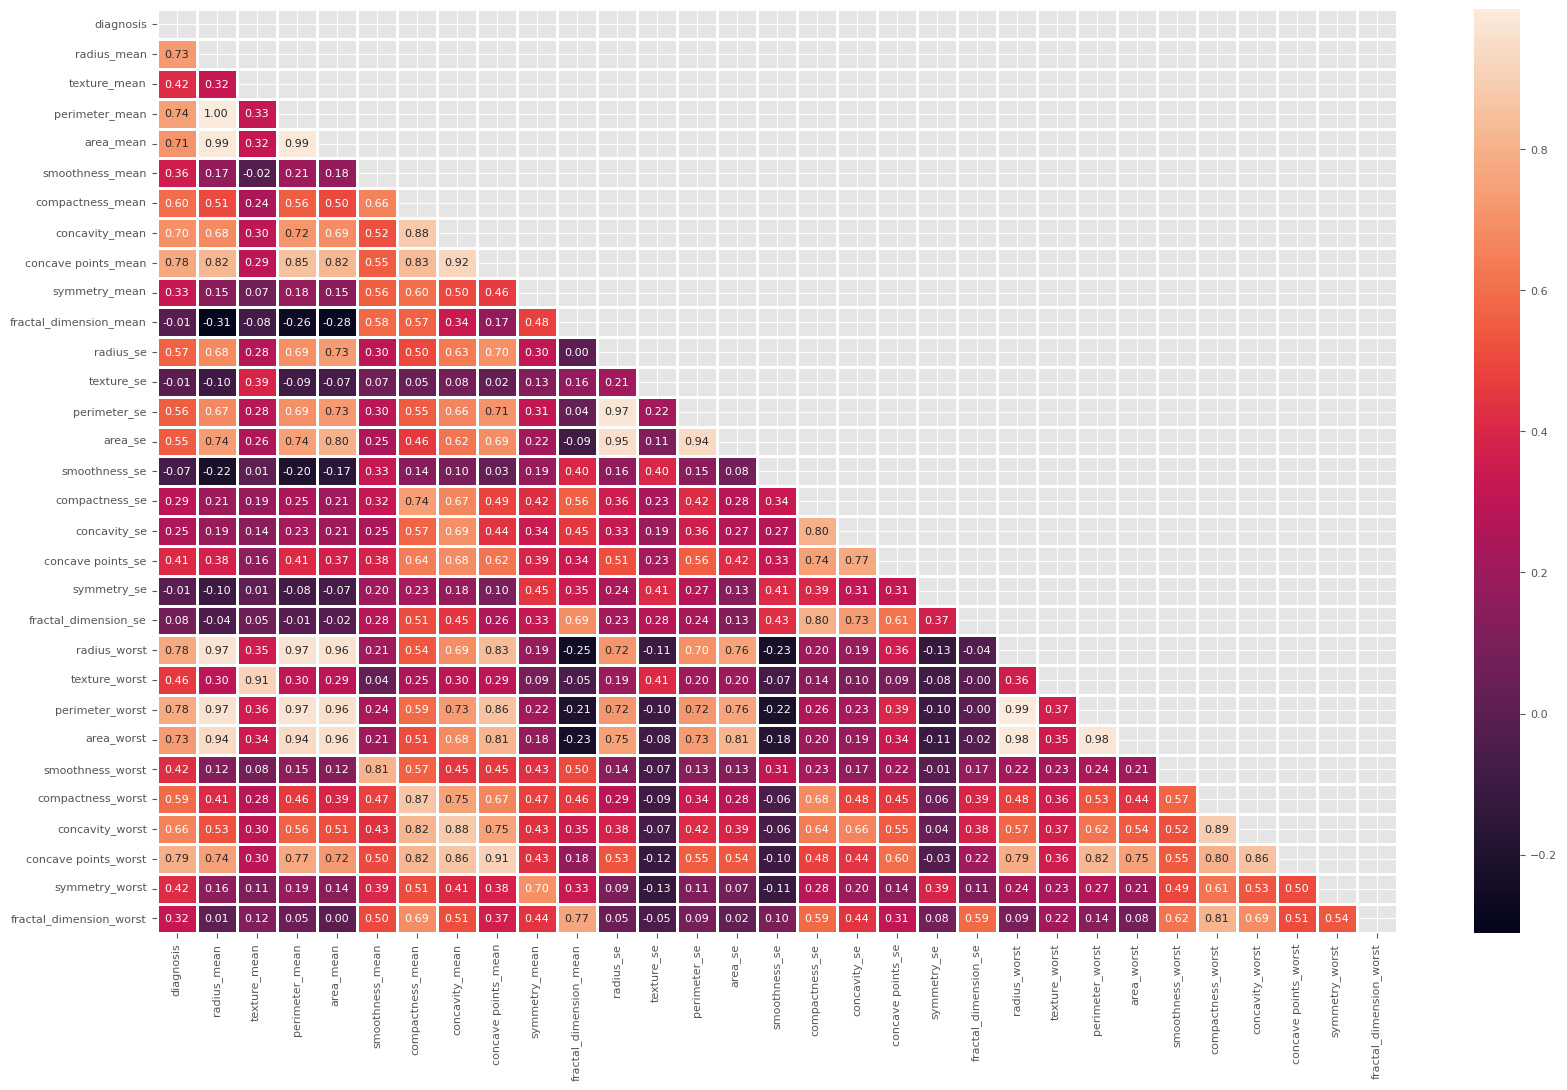

In [13]:
# Korelasyon matrisini çizme
plt.figure(figsize=(20, 12))
corr = df.corr()  # Korelasyon matrisini hesaplama
mask = np.triu(np.ones_like(corr, dtype=bool))  # Üst üçgen maskesi oluşturma
# Isı haritası çizme
sns.heatmap(corr, mask=mask, linewidths=1, annot=True, fmt=".2f")
plt.show()

# Korelasyon matrisinin mutlak değerini alma
corr_matrix = df.corr().abs() 

# Üst üçgen maskesini uygulama
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
tri_df = corr_matrix.mask(mask)


Genel yorumlar:

diagnosis ile diğer özellikler:

radius_mean (0.73), perimeter_mean (0.74), area_mean (0.71) gibi özellikler ile "diagnosis" arasında güçlü pozitif korelasyonlar var. Bu, tümörlerin çapı, çevresi ve alanı büyüdükçe malign olma olasılığının arttığını gösteriyor.
concavity_mean (0.70) ve concave points_mean (0.77) de yüksek korelasyona sahip. Tümörlerin sınırlarının düzensizliği maligniteyle ilişkili.
radius_mean, perimeter_mean ve area_mean:

Bu üç özellik birbirleriyle çok yüksek korelasyona sahip (0.99 civarında). Bu, bu özelliklerin birbirini temsil edebileceğini gösterir. Örneğin, yarıçap büyüdükçe çevre ve alan da doğal olarak artıyor.
concavity_mean ve concave points_mean:

concavity_mean (0.88) ve concave points_mean (0.92) arasında yüksek bir korelasyon var. Tümörlerin şekli ve sınırlarının düzensizliği çok ilişkili özellikler.
radius_worst, perimeter_worst ve area_worst:

Bu "worst" (en kötü) değerler de birbirleriyle çok yüksek korelasyona sahip (0.99 civarında). "Worst" özellikler tümörün en kötü görünen kısmının ölçülerini temsil eder ve maligniteyi daha iyi anlamada yardımcı olabilir.
smoothness_mean ve fractal_dimension_mean:

Bu iki özellik birbirleriyle düşük bir korelasyona sahip. Smoothness tümör yüzeyinin pürüzsüzlüğüyle ilgilidir, fractal dimension ise daha geometrik bir karmaşıklığı gösterir.
compactness_mean ile diğer özellikler:

compactness_mean ile perimeter_mean (0.60) ve area_mean (0.59) gibi özellikler arasında pozitif korelasyon var. Kompaktlık, tümörün şekil olarak ne kadar sıkı olduğunu temsil eder.


Bu bölümde, yüksek korelasyonlu özellikleri (0.92 üzeri) veri çerçevesinden kaldırıyoruz. Yüksek korelasyon, özellikler arasında fazla bilgi tekrarına neden olabilir ve bu da modelin performansını olumsuz etkileyebilir. Bu nedenle, 0.92’den daha yüksek korelasyona sahip özellikleri belirleyip kaldırıyoruz.

Öncelikle, yüksek korelasyona sahip sütunları tespit ediyoruz ve ardından bu sütunları veri çerçevesinden çıkarıyoruz.

In [14]:
# Yüksek korelasyonlu özellikleri kaldırma (0.92 üzeri)
to_drop = [x for x in tri_df.columns if any(tri_df[x] > 0.92)]

# Belirtilen sütunları veri çerçevesinden kaldırma
df = df.drop(to_drop, axis=1)

# Kalan sütun sayısını yazdırma
print(f"The reduced dataframe has {df.shape[1]} columns.")

The reduced dataframe has 23 columns.


# Özellikler ve Etiketleri Ayırma
Bu bölümde, veri çerçevesindeki özellikleri ve etiketleri ayırıyoruz. **X** değişkeni, modelin girdi olarak alacağı özellikleri (özellikler), **y** değişkeni ise modelin tahmin etmeye çalışacağı etiketleri (teşhis) temsil eder.

**diagnosis** sütunu, etiket olarak kullanılırken, diğer tüm sütunlar özellikler olarak kullanılacaktır.

In [15]:
# Özellikler ve etiketleri ayırma
X = df.drop('diagnosis', axis=1)  # Özellikler (X)
y = df['diagnosis']  # Etiket (y)

# Veriyi Eğitim ve Test Setine Ayırma
Bu bölümde, özellikler ve etiketleri kullanarak veriyi eğitim ve test setlerine ayırıyoruz. Eğitim seti, modelin öğrenmesi için kullanılırken, test seti modelin performansını değerlendirmek için kullanılacaktır. Veriyi ayırmak için %30 oranında bir test seti oluşturuyoruz.

Verinin ölçeklendirilmesi, makine öğrenimi algoritmalarının daha iyi performans göstermesi için önemlidir. Bu bölümde, özellikleri standartlaştırmak için StandardScaler kullanıyoruz. Eğitim verisini ölçeklendirdikten sonra, test verisini de aynı ölçeklendirme işlemi ile dönüştürüyoruz.

In [16]:
# Veriyi eğitim ve test setine ayırma
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=0)

# Verileri ölçeklendirme
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

# Eğitim verisini ölçeklendirme
X_train = scaler.fit_transform(X_train)
# Test verisini ölçeklendirme
X_test = scaler.transform(X_test)

# Random Forest Sınıflandırıcısını Oluşturma
Bu bölümde, Random Forest algoritmasını kullanarak bir sınıflandırıcı oluşturuyoruz. Random Forest, birden fazla karar ağacının birleşimiyle çalışan güçlü bir makine öğrenimi modelidir. Modelin parametrelerini belirleyerek, ağaç sayısını, derinliğini ve diğer önemli özellikleri ayarlıyoruz.

Aşağıdaki parametreler kullanılmıştır:
- **criterion**: Modelin kalitesini değerlendirmek için kullanılacak kriter (burada 'entropy' olarak ayarlandı).
- **max_depth**: Ağaçların maksimum derinliği (burada 11 olarak belirlendi).
- **max_features**: Her ağaç için değerlendirilecek maksimum özellik sayısı ('sqrt' kullanılarak, kök değerinin alınması sağlandı).
- **min_samples_leaf**: Bir yaprak düğümde en az kaç örnek olması gerektiği (burada 2 olarak ayarlandı).
- **min_samples_split**: Bir düğümü ayırmak için gereken en az örnek sayısı (burada 3 olarak belirlendi).
- **n_estimators**: Oluşturulacak toplam ağaç sayısı (burada 130 olarak ayarlandı).

In [17]:
# Random Forest sınıflandırıcısını oluşturma
from sklearn.ensemble import RandomForestClassifier
rand_clf = RandomForestClassifier(
    criterion='entropy', 
    max_depth=11, 
    max_features='sqrt',  # 'auto' yerine 'sqrt' kullanma
    min_samples_leaf=2, 
    min_samples_split=3, 
    n_estimators=130
)

# Modeli Eğitim Verisiyle Fit Etme
Bu bölümde, oluşturduğumuz Random Forest sınıflandırıcısını eğitim verisi ile fit ediyoruz. Bu işlem, modelin eğitim verisindeki kalıpları öğrenmesini sağlar.
Model eğitildikten sonra, test verisi üzerinde tahmin yapıyoruz. Bu, modelin genel performansını değerlendirmemize yardımcı olur.
Eğitim seti üzerindeki modelin doğruluk skorunu hesaplıyoruz ve yazdırıyoruz. Bu, modelin eğitim verisine ne kadar iyi uyum sağladığını gösterir.
Test seti üzerindeki modelin doğruluk skorunu hesaplıyor ve yazdırıyoruz. Bu, modelin bilinmeyen veriler üzerindeki performansını gösterir.
Karışıklık matrisini yazarak, modelin tahminlerinin doğru ve yanlış sınıflandırmalarını görsel olarak inceleyeceğiz. Bu, modelin performansını daha detaylı analiz etmemizi sağlar.
Modelin performansını daha ayrıntılı bir şekilde değerlendirmek için sınıflandırma raporunu yazdırıyoruz. Rapor, precision, recall, f1-score gibi önemli metrikleri içerir.

1. Precision (Kesinlik)
Precision, doğru pozitif tahminlerin toplam pozitif tahminlere oranıdır. Yani, modelin pozitif olarak tahmin ettiği örneklerden kaçının gerçekten pozitif olduğunu gösterir. Yüksek precision, modelin pozitif tahminlerinin güvenilir olduğunu gösterir.
2. Recall (Duyarlılık)
Recall, doğru pozitif tahminlerin toplam gerçek pozitif örneklere oranıdır. Bu metrik, modelin gerçek pozitif örnekleri ne kadar iyi tespit ettiğini gösterir. Yüksek recall, modelin pozitif sınıfa ait örnekleri yakalama yeteneğinin iyi olduğunu gösterir.
3. F1-Score
F1-score, precision ve recall'un harmonik ortalamasıdır. İki metrik arasında bir denge kurarak, modelin genel performansını değerlendirir. Yüksek F1-score, hem yüksek precision hem de yüksek recall'a sahip bir modeli işaret eder. Genellikle, sınıflar arasında dengesizlik olduğunda (örneğin, bir sınıf diğerine göre çok daha fazla örneğe sahipse) F1-score, daha iyi bir değerlendirme aracı olabilir.

Yüksek Precision, Düşük Recall: Model pozitif tahminlerde çok dikkatli ama bazı pozitif örnekleri kaçırıyor.
Yüksek Recall, Düşük Precision: Model birçok pozitif örneği yakalıyor ama aynı zamanda çok sayıda yanlış pozitif tahmin de yapıyor.
Yüksek F1-Score: Hem yüksek precision hem de yüksek recall'a sahip, yani model hem doğru tahminler yapıyor hem de önemli pozitif örnekleri kaçırmıyor.

In [18]:
# Modeli eğitim verisiyle fit etme
rand_clf.fit(X_train, y_train)

# Test verisi üzerinde tahmin yapma
y_pred = rand_clf.predict(X_test)

# Eğitim seti için doğruluk skorunu yazdırma
print(accuracy_score(y_train, rand_clf.predict(X_train)))

# Test seti için doğruluk skorunu hesaplama ve yazdırma
ran_clf_acc = accuracy_score(y_test, y_pred)
print(ran_clf_acc)

# Karışıklık matrisini yazdırma
print(confusion_matrix(y_test, y_pred))

# Sınıflandırma raporunu yazdırma (precision, recall, f1-score vb.)
print(classification_report(y_test, y_pred))

0.9949748743718593
0.9649122807017544
[[107   1]
 [  5  58]]
              precision    recall  f1-score   support

           0       0.96      0.99      0.97       108
           1       0.98      0.92      0.95        63

    accuracy                           0.96       171
   macro avg       0.97      0.96      0.96       171
weighted avg       0.97      0.96      0.96       171



# ROC
Bu bölümde, modelin sınıflandırma performansını değerlendirmek için ROC eğrisi ve AUC (Eğri Altında Kalan Alan) hesaplıyoruz. ROC eğrisi, yanlış pozitif oranına (FPR) karşı doğru pozitif oranını (TPR) gösteren bir grafik olup, modelin farklı eşik değerleri için performansını görselleştirir. AUC, bu eğrinin altında kalan alanı temsil eder ve modelin genel başarısını ölçer.

 Adımlar:

1. **Tahmin Edilen Olasılıkları Alma**: Modelin test verisi üzerinde pozitif sınıf için tahmin edilen olasılıkları alıyoruz.
2. **ROC Eğrisini Hesaplama**: Gerçek etiketler ile tahmin edilen olasılıkları kullanarak ROC eğrisini hesaplıyoruz.
3. **AUC Hesaplama**: ROC eğrisi altında kalan alanı hesaplayarak modelin genel performansını değerlendiriyoruz.

In [19]:
# Gerekli kütüphaneleri içe aktarma
from sklearn.metrics import roc_curve, auc

# ROC eğrisi için gerçek etiketler ve tahmin edilen olasılıkları al
y_probs = rand_clf.predict_proba(X_test)[:, 1]  # Pozitif sınıf için olasılıkları al

# ROC eğrisini hesapla
fpr, tpr, thresholds = roc_curve(y_test, y_probs)

# AUC'yi hesapla
roc_auc = auc(fpr, tpr)

print(roc_auc)

0.9983833039388595


# ROC Eğrisini Çizme
Bu bölümde, modelin sınıflandırma performansını daha iyi görselleştirmek için ROC eğrisini çiziyoruz. ROC eğrisi, modelin farklı eşik değerlerinde yanlış pozitif oranına (FPR) karşı doğru pozitif oranını (TPR) gösterir. Eğri, modelin genel performansını anlamamıza yardımcı olur. AUC (Eğri Altında Kalan Alan) değeri, modelin genel başarı düzeyini temsil eder.

### Grafik Öğeleri:
- **Mavi Eğri**: Modelin ROC eğrisi.
- **Kırmızı Düz Çizgi**: Rastgele sınıflandırıcı çizgisi, idealde bu çizginin üstünde kalmak istenir.
- **X ve Y Eksenleri**: Yanlış pozitif oran ve doğru pozitif oranı.

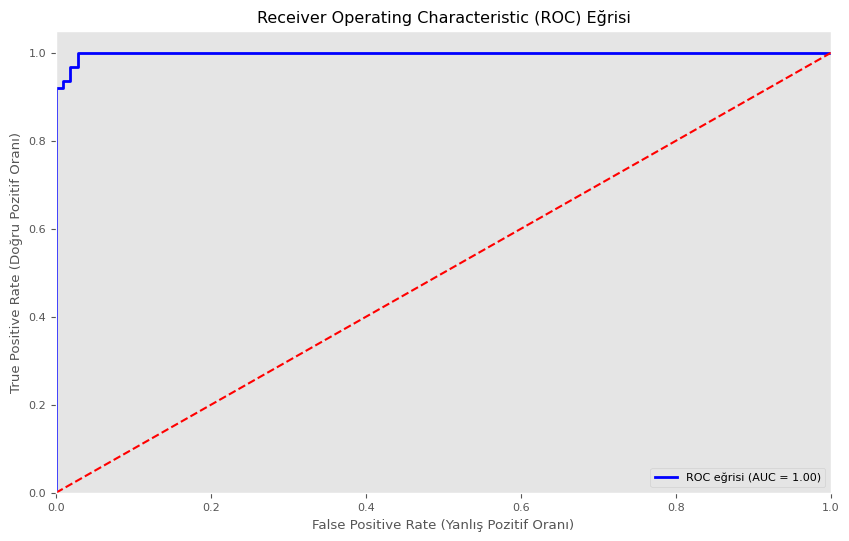

In [20]:
# ROC eğrisini çizme
plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label='ROC eğrisi (AUC = {:.2f})'.format(roc_auc))
plt.plot([0, 1], [0, 1], color='red', linestyle='--')  # Rastgele sınıflandırıcı çizgisi
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (Yanlış Pozitif Oranı)')
plt.ylabel('True Positive Rate (Doğru Pozitif Oranı)')
plt.title('Receiver Operating Characteristic (ROC) Eğrisi')
plt.legend(loc='lower right')
plt.grid()
plt.show()